In [ ]:
!pip install yfinance

/tmp/ipykernel_1515/2148861592.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


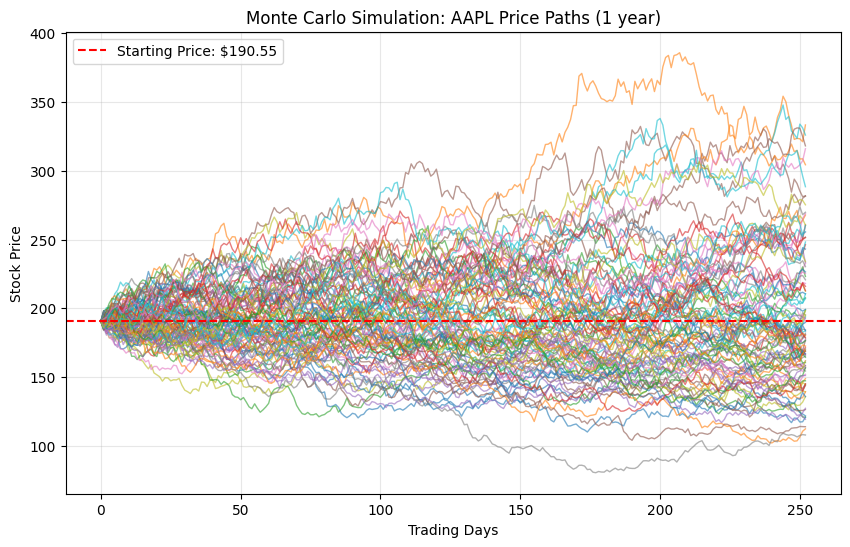

Mean Final Price: $195.80
Median Final Price: $182.72
Standard Deviation: $52.62
Monte Carlo Call Price: $22.69


In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ticker = "AAPL"
start_date = "2022-01-01"
end_date = "2024-01-01"

stock_data = yf.download(ticker, start=start_date, end=end_date)

stock_data['Log_Returns'] = np.log(stock_data['Close'] / stock_data['Close'].shift(1))

stock_data = stock_data.dropna()

P_0 = stock_data['Close'].iloc[-1]

daily_volatility = stock_data['Log_Returns'].std()
sigma = daily_volatility * np.sqrt(252)

r = 0.05


###

t = 1
n_steps = 252
dt = t/n_steps
n_sims = 100

S = np.zeros((n_steps + 1, n_sims))
S[0] = P_0

for t_step in range(1, n_steps + 1):
  z = np.random.standard_normal(n_sims)

  drift = (r-0.5*sigma**2)*dt
  shock = sigma * np.sqrt(dt) * z

  S[t_step] = S[t_step-1] * np.exp(drift + shock)

plt.figure(figsize=(10,6))
plt.plot(S[:, :100], lw=1, alpha=0.6)

plt.title(f"Monte Carlo Simulation: {ticker} Price Paths (1 year)")
plt.xlabel("Trading Days")
plt.ylabel("Stock Price")
plt.axhline(y=P_0.item(), color='r', linestyle='--', label=f"Starting Price: ${P_0.item():.2f}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

final_prices = S[-1]
mean_price = np.mean(final_prices)
std_price = np.std(final_prices)
median_price = np.median(final_prices)

print(f"Mean Final Price: ${mean_price:.2f}")
print(f"Median Final Price: ${median_price:.2f}")
print(f"Standard Deviation: ${std_price:.2f}")

K = P_0.item() ###We assume here that strike price is equal to starting price
payoffs = np.maximum(final_prices - K, 0)
expected_payoff = np.mean(payoffs)

discount_factor = np.exp(-r*t)
monte_carlo_call_price = expected_payoff * discount_factor

print(f"Monte Carlo Call Price: ${monte_carlo_call_price:.2f}")


In [ ]:
print(f"Starting Price (P_0): ${P_0.item():.2f}")
print(f"Annualized Volatility (Sigma): {sigma:.4f}")

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd

def price_monte_carlo_call(ticker, K=None, t=1.0, r=0.05, n_sims=100, n_steps=252):

  stock_data = yf.download(ticker, period="2y", progress=False)
  stock_data['Log_Returns'] = np.log(stock_data['Close'] / stock_data['Close'].shift(1))
  stock_data = stock_data.dropna()

  P_0 = stock_data['Close'].iloc[-1]
  daily_volatility = stock_data['Log_Returns'].std()

  sigma = daily_volatility * np.sqrt(252)

  dt = t/n_steps

  S = np.zeros((n_steps + 1, n_sims))
  S[0] = P_0

  for t_step in range(1, n_steps + 1):
    z = np.random.standard_normal(n_sims)

    drift = (r-0.5*sigma**2)*dt
    shock = sigma * np.sqrt(dt) * z

    S[t_step] = S[t_step-1] * np.exp(drift + shock)

  final_prices = S[-1]

  if K is None:
    K = P_0.item()

  payoffs = np.maximum(final_prices - K, 0)
  expected_payoff = np.mean(payoffs)
  discount_factor = np.exp(-r*t)
  monte_carlo_call_price = expected_payoff * discount_factor

  return{
      "Ticker": ticker,
      "Call Price": round(float(monte_carlo_call_price), 2),
      "Strike Price": round(K, 2)
  }


print(price_monte_carlo_call("AAPL"))


/tmp/ipykernel_16432/1362292002.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(ticker, period="2y", progress=False)


{'Ticker': 'AAPL', 'Call Price': 29.88, 'Strike Price': 272.59}


/tmp/ipykernel_16432/2661317203.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(ticker, period="2y", progress=False)


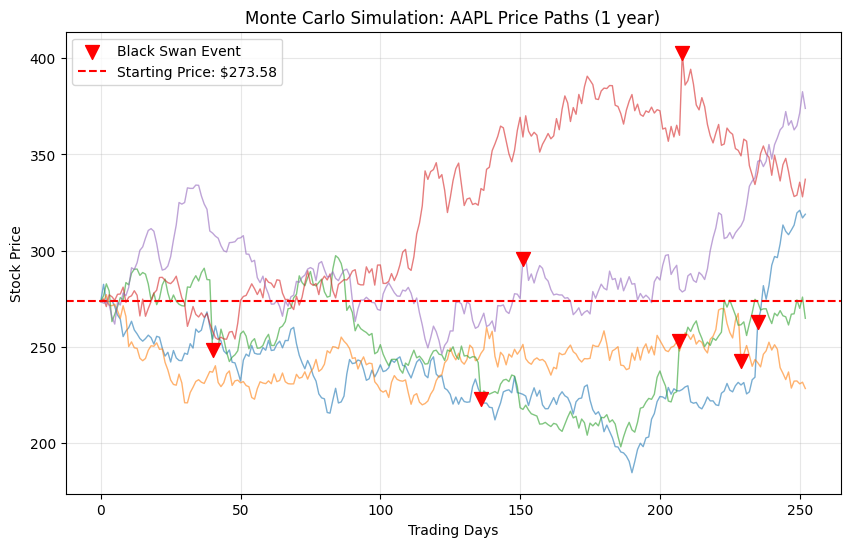

{'Ticker': 'AAPL', 'Call Price': 30.91, 'Strike Price': 273.58}


In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def bswan_price_monte_carlo_call(ticker, K=None, t=1.0, r=0.05, n_sims=100, n_steps=252, freq=1/252, delta=0.1, plt_sims=5):

  stock_data = yf.download(ticker, period="2y", progress=False)
  stock_data['Log_Returns'] = np.log(stock_data['Close'] / stock_data['Close'].shift(1))
  stock_data = stock_data.dropna()

  P_0 = stock_data['Close'].iloc[-1]
  daily_volatility = stock_data['Log_Returns'].std()

  sigma = daily_volatility * np.sqrt(252)

  dt = t/n_steps

  S = np.zeros((n_steps + 1, n_sims))
  S[0] = P_0

  rng = np.random.default_rng()


  jump_days = []
  jump_prices = []

  for t_step in range(1, n_steps + 1):
    z = np.random.standard_normal(n_sims)

    drift = (r-0.5*sigma**2)*dt
    shock = sigma * np.sqrt(dt) * z

    swing_occurs = np.random.rand(n_sims) < freq
    swing_multiplier = np.ones(n_sims)

    num_swings = np.sum(swing_occurs)
    if num_swings > 0:
      directions = rng.choice([-1,1], size=num_swings)
      swing_multiplier[swing_occurs] = 1 + delta * directions


    S[t_step] = S[t_step-1] * np.exp(drift + shock) * swing_multiplier

    for i in range (plt_sims):
      if swing_occurs[i]:
        jump_days.append(t_step)
        jump_prices.append(S[t_step, i].item())

  final_prices = S[-1]

  if K is None:
    K = P_0.item()

  payoffs = np.maximum(final_prices - K, 0)
  expected_payoff = np.mean(payoffs)
  discount_factor = np.exp(-r*t)
  monte_carlo_call_price = expected_payoff * discount_factor

  ##### Making a plot


  plt.figure(figsize=(10,6))
  plt.plot(S[:, :plt_sims], lw=1, alpha=0.6)
  plt.scatter(jump_days, jump_prices, color='red', marker='v', s=100, zorder=5, label='Black Swan Event')

  plt.title(f"Monte Carlo Simulation: {ticker} Price Paths (1 year)")
  plt.xlabel("Trading Days")
  plt.ylabel("Stock Price")
  plt.axhline(y=P_0.item(), color='r', linestyle='--', label=f"Starting Price: ${P_0.item():.2f}")
  plt.legend()
  plt.grid(True, alpha=0.3)
  plt.show()

  return{
      "Ticker": ticker,
      "Call Price": round(float(monte_carlo_call_price), 2),
      "Strike Price": round(K, 2)
  }





print(bswan_price_monte_carlo_call("AAPL"))